### Dataset Information
This demo notebook uses 10X single-cell multiomics data from developing human cortex, originally generated by Trevino et al. (Cell, 2021). The preprocessed data used in this analysis was processed by Li et al. (Nature Biotechnology, 2023).

### Data Sources
The dataset consists of paired RNA and ATAC-seq measurements:

RNA data: https://figshare.com/articles/dataset/Developing_Human_Cortex_RNA_Data/22575376 \
ATAC data:https://figshare.com/articles/dataset/Developing_Human_Cortex_ATAC_Data/22575370

Preprocessed Data provided by Li et al. (Nature Biotechnology, 2023)

### Cell Type Annotations
We use the original cell type annotations from Trevino et al. The annotation file is provided as `data/humancortex_cell_annotations.tsv` in GitHub repository.

### References

Trevino, A.E., M¨uller, F., Andersen, J., Sundaram, L., Kathiria, A., Shcherbina,
A., Farh, K., Chang, H.Y., Pas, ca, A.M., Kundaje, A., et al.: Chromatin and
gene-regulatory dynamics of the developing human cerebral cortex at single-cell resolution. Cell 184(19), 5053–5069 (2021)\
Li, C., Virgilio, M.C., Collins, K.L., Welch, J.D.: Multi-omic single-cell velocity
models epigenome–transcriptome interactions and improves cell fate prediction.
Nature biotechnology 41(3), 387–398 (2023)

In [1]:
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import scanpy as sc
import scvelo as scv

In [3]:
import sys
sys.path.append('../src/')

In [4]:
import MoFlow as mf

### Data Loading and MoFlow Analysis
Load the preprocessed RNA and ATAC-seq data and run the MoFlow algorithm

In [5]:
adata_rna = anndata.read_h5ad('../data/Human_brain/adata_postpro.h5ad')
adata_atac = anndata.read_h5ad('../data/Human_brain/adata_atac_postpro.h5ad')

In [20]:
celltype_new = pd.read_csv('../data/humancortex_cell_annotations.tsv', sep=',',
           index_col=0)

In [21]:
adata_rna.obs['celltype_new'] = celltype_new

In [8]:
moflow_ = mf.MOFlow(adata_rna,
                    adata_atac,
                   folder_name='MoFlow_velocity_Human_brain')

Using /home/elly924/workspace/proj/2025/MoFlow_proj/MoFlow_velocity_Human_brain as the output path.


In [ ]:
# This will take a while. 
moflow_.velocity(adata_rna, n_jobs=10, save_path='data/Human_brain/', 
                 file_name='adata_moflow.h5ad')

Arranging genes for parallel job.
954  genes were arranged to  96  portions.



Velocity Estimation:   2%|▏         | 2/96 [00:16<11:59,  7.66s/it]

### Velocity Stream and Psueodimte Computation
Compute RNA velocity streams and infer developmental pseudotime using the `scVelo` framwork

In [6]:
adata_result = anndata.read_h5ad('../data/Human_brain/adata_moflow.h5ad')

In [ ]:
scv.tl.velocity_graph(adata_result, xkey='s', vkey='velo_s')

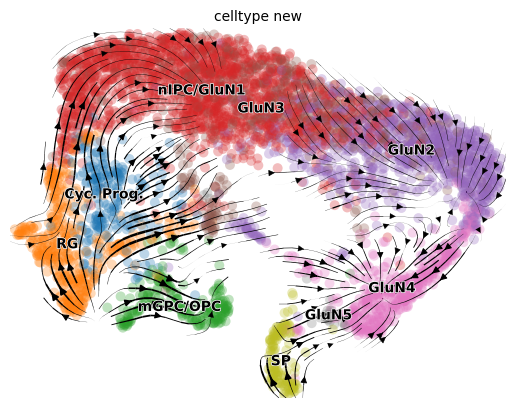

In [7]:
scv.pl.velocity_embedding_stream(adata_result, vkey='velo_s', color='celltype_new')

In [ ]:
scv.tl.velocity_pseudotime(adata_result, vkey='velo_s')

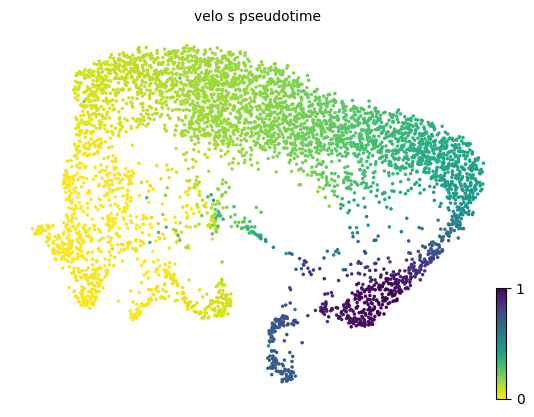

In [8]:
scv.pl.scatter(adata_result, color='velo_s_pseudotime')

In [39]:
adata_result.write_h5ad('../data/Human_brain/adata_moflow.h5ad')

In [9]:
adata_result = anndata.read_h5ad('../data/Human_brain/adata_moflow.h5ad')

### Algorithm Evaluation
Evalutate trajectory inference performance using the CBDir metric.\
Higher CBDir values indicate better directional accuracy based on known developmental trajectories

In [33]:
cluster_edges = (('Cyc. Prog.', 'RG'), ('RG',  'nIPC/GluN1'), ('RG','mGPC/OPC' ), ('nIPC/GluN1', 'GluN2'),
                 ('nIPC/GluN1', 'GluN3'), ('GluN3', 'GluN2'), ('GluN2', 'GluN4'), ('GluN5', 'GluN4'),
                 ('SP', 'GluN4'), ('SP', 'GluN5'))

In [36]:
cbdir = {}
cbdir['moflow'] = mf.cross_boundary_correctness(adata_result, 'celltype_new', 'velo_s', cluster_edges,
                                          True, 'X_umap')
cbdir['multivelo'] = mf.cross_boundary_correctness(multivelo_result, 'celltype_new', 'velo_s_norm', cluster_edges,
                                          True, 'X_umap')

In [37]:
cbdir_ = []
for k in cbdir.values():
    temp = {}
    for c, s in k.items():
        s = np.mean(s)
        temp[c] = s
    cbdir_.append(temp)
    
cbdir_ = pd.DataFrame(cbdir_, index=cbdir.keys())

cbdir_.mean(axis=1)
#higher cbdir, better 

moflow       0.362190
multivelo    0.127731
dtype: float64

### Gene Scoring Analysis
Calcuate gene regulatory scores using two metrices:
* m1/m2 score: regulatory dynamics during initiation of transcription repression.
* RNA-on/off score: soverall gene expression dynamics.

In [22]:
model_df = mf.eval.get_genescore(adata_result)

In [23]:
model_df

,on,off,m1,m2
ABCC9,0.934363,0.000000,0.711864,0.288136
ABHD3,0.060606,0.374053,0.308480,0.691520
ABLIM1,0.121893,0.344379,0.258333,0.741667
ABLIM3,0.333333,0.009259,0.965699,0.034301
ABTB2,0.506891,0.001531,0.910791,0.089209
...,...,...,...,...
ZNF385B,0.546584,0.000000,0.794872,0.205128
ZNF385D,0.289474,0.254386,0.697436,0.302564
ZNF521,0.470106,0.017585,0.716981,0.283019
ZNF536,0.267728,0.095514,0.567568,0.432432


In [24]:
#Compare with multivelo result
multivelo_result = anndata.read_h5ad(
    '../data/Human_brain/adata_multivelo.h5ad')

In [26]:
genelist = set(adata_result.var_names) & set(multivelo_result.var_names)
adata_result_ = adata_result[:, adata_result.var_names.isin(genelist)]
multivelo_result_ = multivelo_result[:, multivelo_result.var_names.isin(genelist)]

In [27]:
model_df_ = model_df.loc[ multivelo_result_.var_names.values]
model_df_['fit_model'] = multivelo_result_.var['fit_model']
model_df_['fit_direction'] = multivelo_result_.var['fit_direction']

[Text(0, 0, 'Model1'), Text(1, 0, 'Model2')]

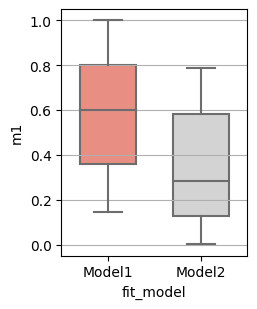

In [28]:
#Compare m1 score of Model1 or Model2 gene
fig, ax = plt.subplots(figsize=(2.4, 3.2))
sns.boxplot(data=model_df_, y='m1', x='fit_model',
             palette=['salmon', 'lightgrey'],  
             width=.6, whis=.5, showfliers=False)
ax.grid(axis='y')
ax.set_xticklabels(['Model1', 'Model2'])

[Text(0, 0, 'Model1'), Text(1, 0, 'Model2')]

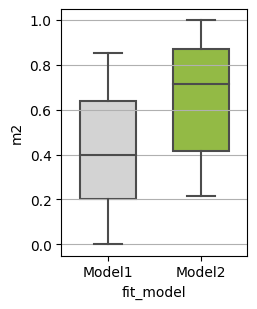

In [29]:
#Compare m2 score of Model1 or Model2 gene
fig, ax = plt.subplots(figsize=(2.4, 3.2))
sns.boxplot(data=model_df_, y='m2', x='fit_model',
              palette=['lightgrey', 'yellowgreen'],
             width=.6, whis=.5, showfliers=False)
ax.grid(axis='y')
ax.set_xticklabels(['Model1', 'Model2'])

## Individual Gene Analysis

In [40]:
gene_list=['MKI67','BCL11B', 'CREB5', 'SDK2', 'RFX4']

### Phase Portraits Visualization
Generate pahse portraits for individual genes in 2D or 3D dimensional spaces to visualize regulatory dynamics

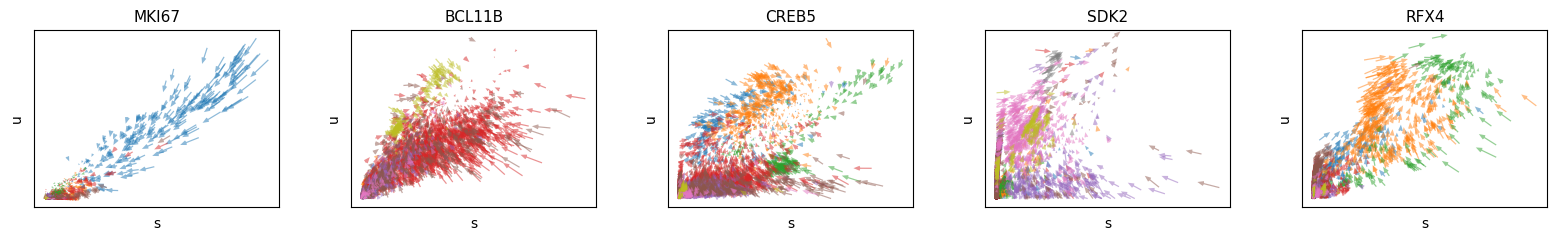

In [43]:
#plot scatter plot of genes with velocity arrows to show the predicted directions
fig, axes = mf.scatter_gene(adata_result,
    gene_list=gene_list,
    color_by='celltype_new',
    velocity_arrows=True,
    )
for ax in axes[0]:
    ax.set_xticks([])
    ax.set_yticks([])

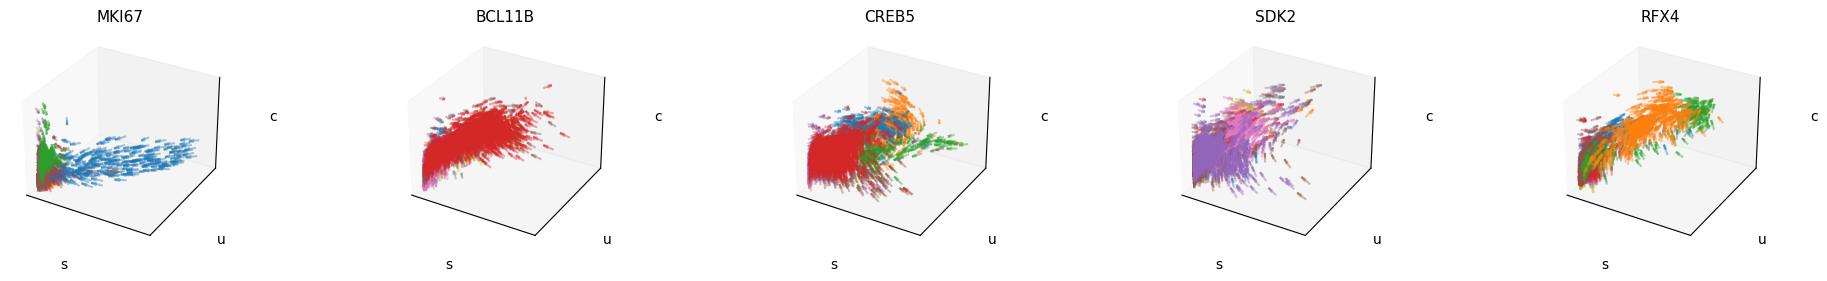

In [46]:
#3D phase portraits
fig, axes = mf.scatter_gene(adata_result,
    gene_list=gene_list,
    color_by='celltype_new',
    velocity_arrows=True, by='cus'
    )
for ax in axes[0]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

### Expression vs Pseudotime Analysis
Examine RNA expression levels and chromatin accessibility profiles as functions of developmenal pseudotime

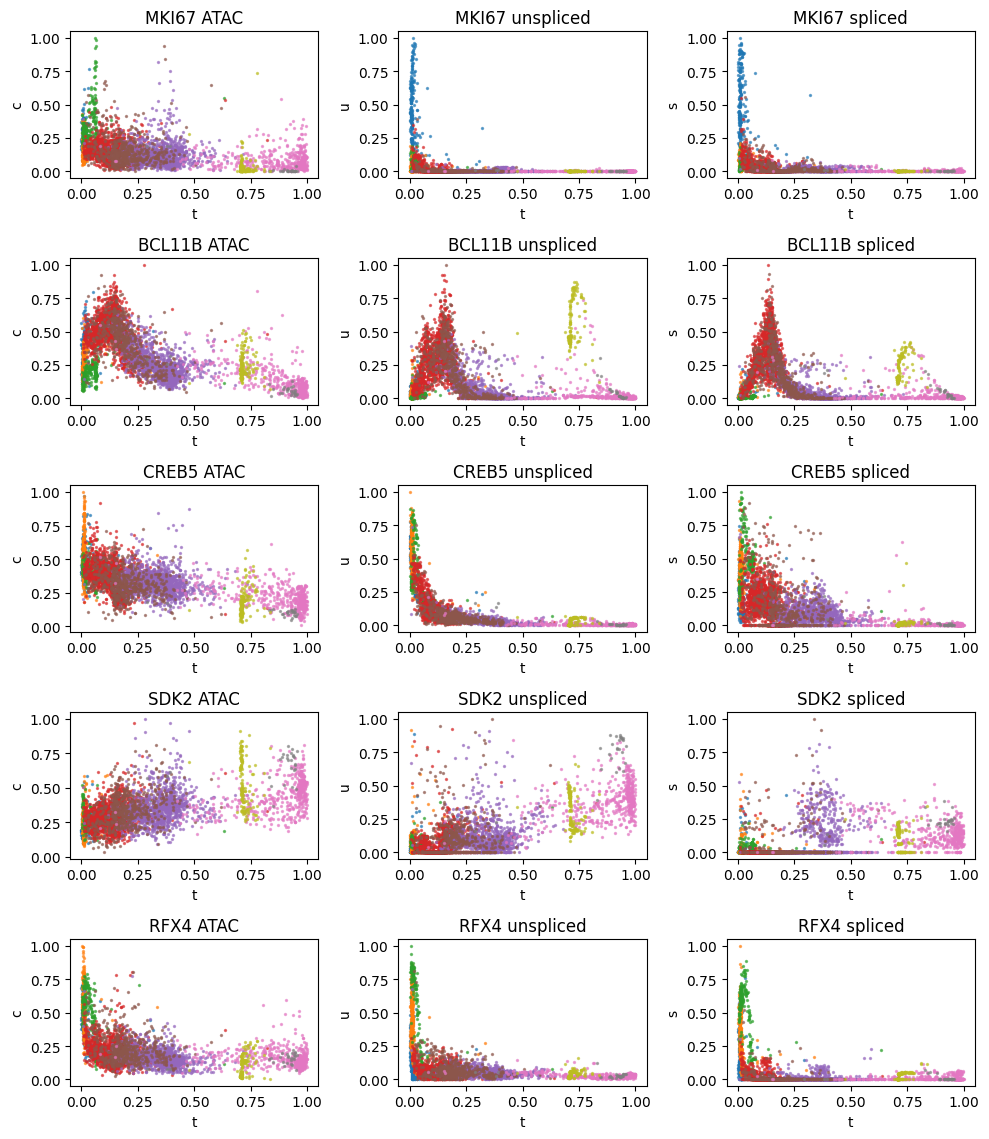

In [49]:
fig, axes = mf.dynamic_plot(adata_result, gene_list=gene_list,
                color_by='celltype_new')

### Dynamic Time Wraping Analysis
Examine DTW between expressions or chromatin aceesibility profiles along pseudotime

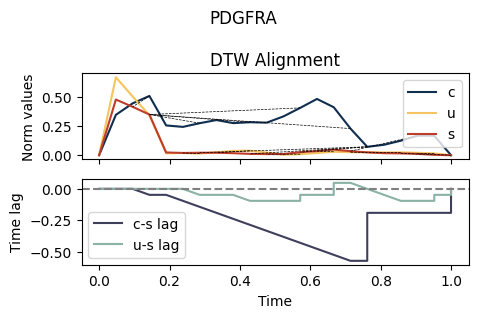

In [6]:
#do DTW analysis and get plot for selected gene
mf.eval_dtw.plot_dtw(adata_result, 'PDGFRA',
                    )